In [207]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)
import numpy as np
from sklearn.model_selection import ParameterGrid

from darts.timeseries import TimeSeries
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.dataprocessing.transformers import Scaler
from darts.models import RNNModel

In [208]:
df: pd.DataFrame = pd.read_csv("nyc_data.csv", index_col="Date", parse_dates=True)
df.head()

,Demand,Easter,Thanksgiving,Christmas,Temperature,Marketing
Date,,,,,,
2015-01-01,720.000885,0,0,0,3.68,41.305
2015-01-02,581.276773,0,0,0,4.73,131.574
2015-01-03,754.117039,0,0,0,7.23,162.700
2015-01-04,622.252774,0,0,0,10.96,160.281
2015-01-05,785.373319,0,0,0,6.92,51.077


In [209]:
df.index.freq = "D"
df.index

DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04',
               '2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
               '2015-01-09', '2015-01-10',
               ...
               '2020-12-22', '2020-12-23', '2020-12-24', '2020-12-25',
               '2020-12-26', '2020-12-27', '2020-12-28', '2020-12-29',
               '2020-12-30', '2020-12-31'],
              dtype='datetime64[us]', name='Date', length=2192, freq='D')

In [210]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2192 entries, 2015-01-01 to 2020-12-31
Freq: D
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Demand        2192 non-null   float64
 1   Easter        2192 non-null   int64  
 2   Thanksgiving  2192 non-null   int64  
 3   Christmas     2192 non-null   int64  
 4   Temperature   2192 non-null   float64
 5   Marketing     2192 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 119.9 KB


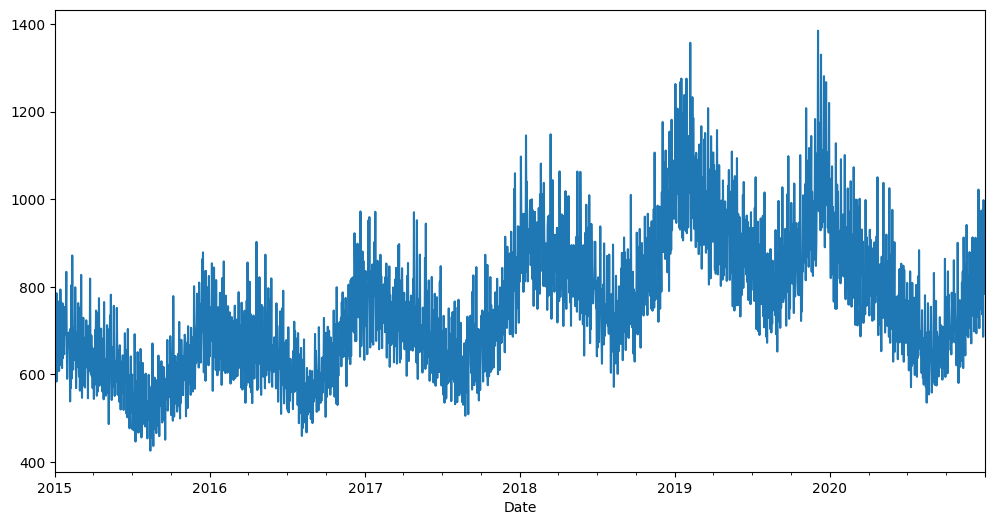

In [211]:
df = df.rename(columns={"Demand": "y"})
df["y"].plot(figsize=(12, 6))
plt.show()

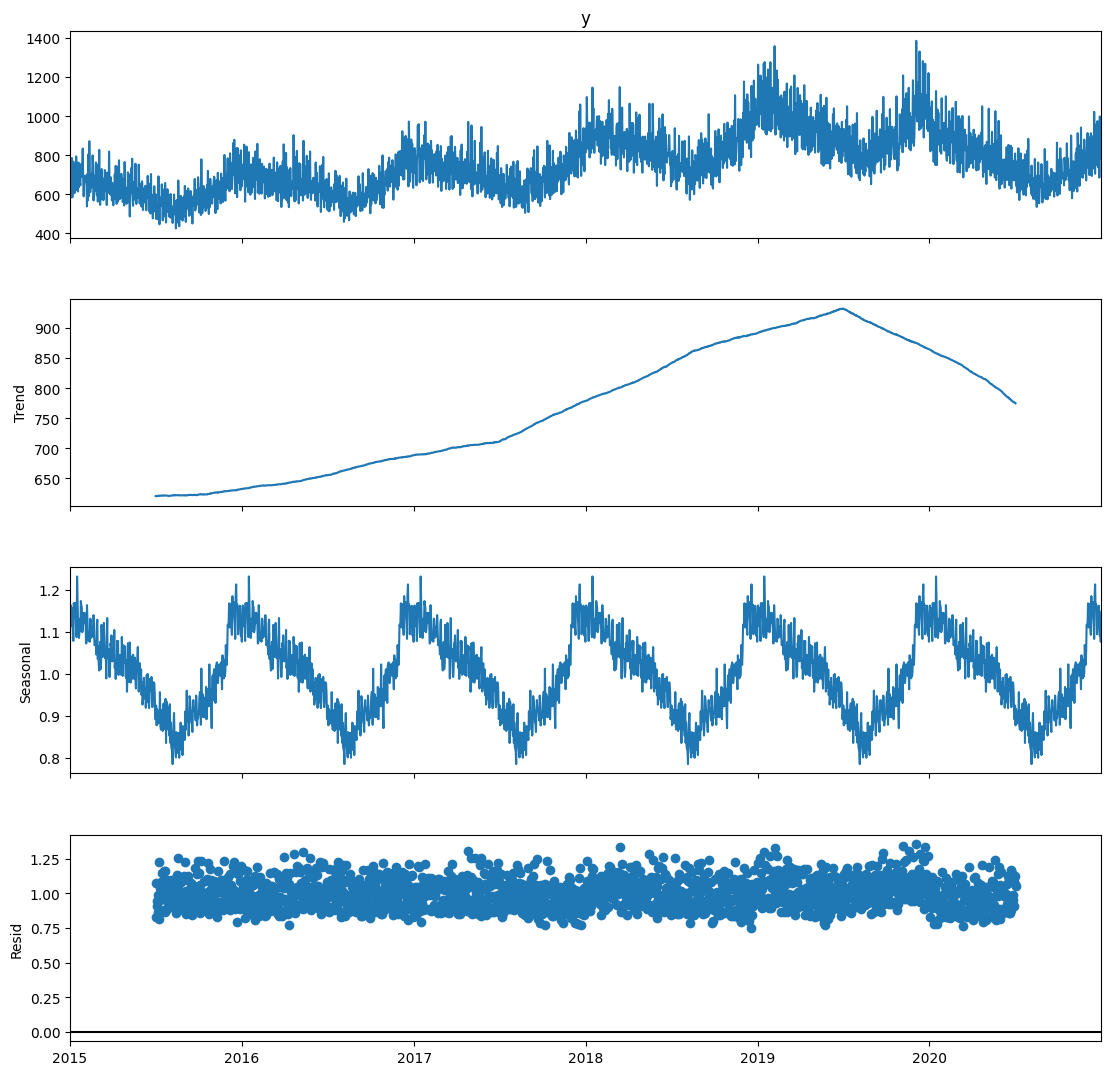

In [212]:
seas_dec = seasonal_decompose(df["y"], model="mul", period=365)

fig = seas_dec.plot()
fig.set_size_inches(12, 12)
plt.show()

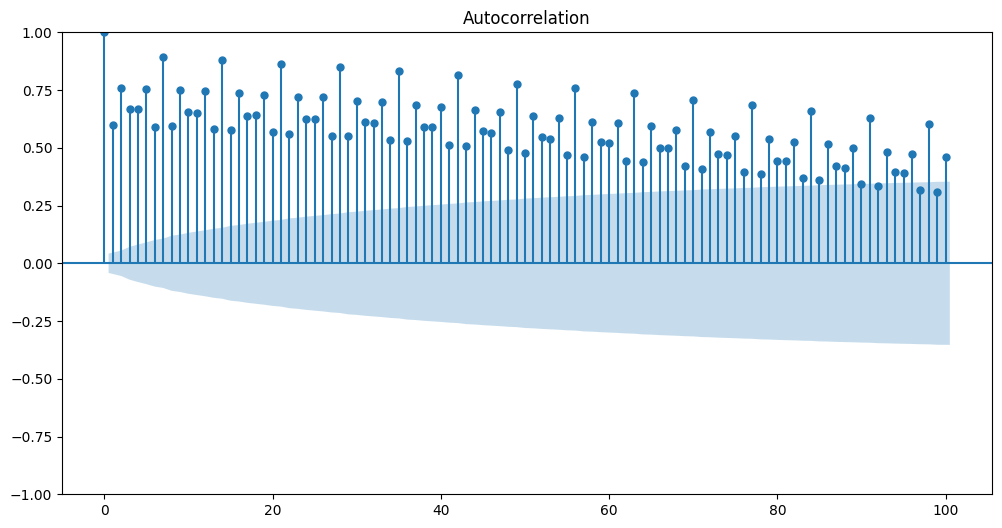

In [213]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(df["y"], lags=100, ax=ax)
plt.show()

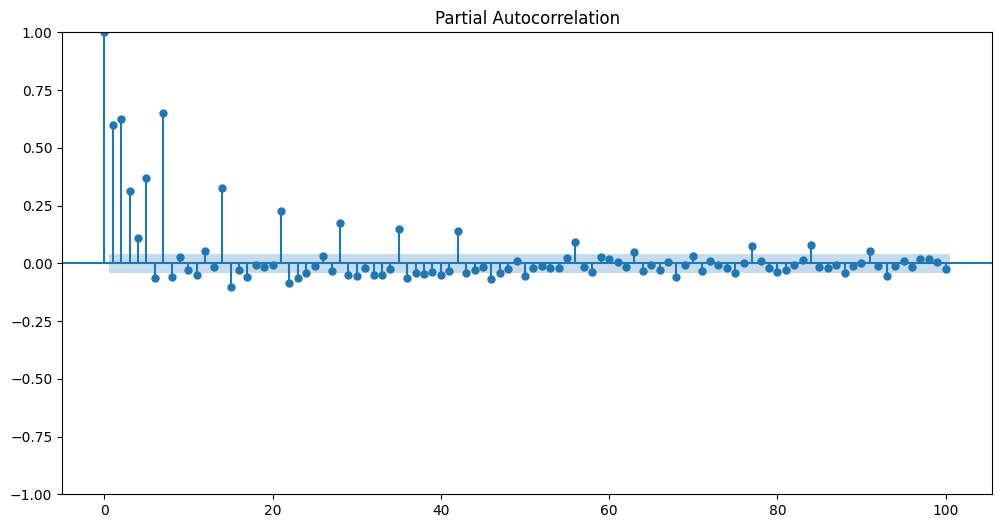

In [214]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_pacf(df["y"], lags=100, ax=ax)
plt.show()

In [215]:
series = TimeSeries.from_series(df["y"])
covariates = TimeSeries.from_dataframe(df.iloc[:, 1:])
covariates

,Easter,Thanksgiving,Christmas,Temperature,Marketing
Date,,,,,
2015-01-01,0.0,0.0,0.0,3.68,41.305
2015-01-02,0.0,0.0,0.0,4.73,131.574
2015-01-03,0.0,0.0,0.0,7.23,162.700
2015-01-04,0.0,0.0,0.0,10.96,160.281
2015-01-05,0.0,0.0,0.0,6.92,51.077
...,...,...,...,...,...
2020-12-27,0.0,0.0,0.0,2.89,38.674
2020-12-28,0.0,0.0,0.0,8.83,166.712
2020-12-29,0.0,0.0,0.0,3.48,161.865


In [216]:
# Create the time variables
year = datetime_attribute_timeseries(series, attribute="year", one_hot=False)
month = datetime_attribute_timeseries(series, attribute="month", one_hot=False)
weekday = datetime_attribute_timeseries(series, attribute="weekday", one_hot=False)

In [217]:
# Prepare the scalers
series_scaler = Scaler()
covariates_scaler = Scaler()

series_scaled = series_scaler.fit_transform(series=series)

In [218]:
# stack the time variables to the covariates
for var in [year, month, weekday]:
    covariates = covariates.stack(var)

In [219]:
covariates = covariates_scaler.fit_transform(covariates)

In [220]:
forecasting_horizon = 31
input_chunk_length = 46  # deve essere più grande del forecasting horizon

In [221]:
# LSTM building (RNN)

model = RNNModel(
    model="LSTM",
    input_chunk_length=input_chunk_length,
    hidden_dim=25,
    n_rnn_layers=2,
    dropout=0,
    training_length=input_chunk_length + forecasting_horizon,
    n_epochs=10,
    random_state=1502,
    optimizer_kwargs={"lr": 0.03},
    # pl_trainer_kwargs={"accelerator": "gpu", "devices": [0]}, # solo se è abilitata gpu
)

ImportError: The `(Py)Torch` module could not be imported. To enable (Py)Torch support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


ImportError: The `(Py)Torch` module could not be imported. To enable (Py)Torch support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md

In [ ]:
model.fit(series_scaled, future_covariates=covariates, verbose=True)